# Summary SimFin

Health check + coverage report for SimFin data in the local DuckDB.

SimFin writes four tables: **`income`**, **`balance`**, **`cashflow`** (financial statements) and **`companies`** (metadata).

Row-level retrieval goes through `irp.data.simfin.fundamentals()` / `companies()`. Aggregations stay in SQL via the shared `db()` connection.

In [1]:
import pandas as pd
from IPython.display import display

from irp.data._common import db
from irp.data.simfin import companies as _companies
from irp.data.simfin import fundamentals

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

In [2]:
_META = {
    'Ticker',
    'SrcId',
    'Src',
    'Currency',
    'Fiscal Year',
    'Fiscal Period',
    'Report Date',
    'Publish Date',
    'Restated Date',
    'Market',
    'Period',
}


def summarize(df: pd.DataFrame, name: str) -> None:
    display(df.dtypes.to_frame('dtype'))
    tickers = sorted(df['Ticker'].unique())
    items = [c for c in df.columns if c not in _META]
    print(f'=== {name} ===')
    print(f'Rows: {len(df):,}  |  Tickers: {len(tickers)}')
    print(
        f'Fiscal Year : {int(df["Fiscal Year"].min())} – {int(df["Fiscal Year"].max())}'
    )
    print(
        f'Report Date : {df["Report Date"].min().date()} – {df["Report Date"].max().date()}'
    )
    print(f'\nTickers ({len(tickers)}): {", ".join(tickers)}')
    print(f'\nStatement items ({len(items)}):')
    for col in items:
        n = df[col].notna().sum()
        print(f'  {col:<50s}  {n:>6,}  ({100 * n / len(df):.0f}%)')

## Tables

Schema, row count, and key stats for each table written by `irp.sources.sim_fin.SimFinSource`.

### `income` / `balance` / `cashflow`

One row per (Ticker, Fiscal Year, Fiscal Period, Period). `Period` is `'A'` (annual) or `'Q'` (quarterly).

| Column | Type | Meaning |
|---|---|---|
| Ticker | VARCHAR | Uppercase symbol |
| Fiscal Year | BIGINT | Calendar year the fiscal year ends |
| Fiscal Period | VARCHAR | `FY`, `Q1`–`Q4` |
| Period | VARCHAR | `A` or `Q` |
| Report Date | DATE | Date financials were reported |
| Currency | VARCHAR | Reporting currency (e.g. `USD`) |
| SrcId | VARCHAR | SimFin ticker ID |
| Src | VARCHAR | Always `simfin` |
| *(line items)* | DOUBLE | Statement-specific financial items |

In [3]:
income_A = fundamentals(statement='income', variant='A')
income_Q = fundamentals(statement='income', variant='Q')
income = pd.concat([income_A, income_Q])

In [4]:
summarize(income, 'Income Statement')

,dtype
Ticker,str
SrcId,int64
Src,str
Currency,str
Fiscal Year,int64
Fiscal Period,str
Report Date,datetime64[us]
Publish Date,datetime64[us]
Restated Date,datetime64[us]
Shares (Basic),Int64


=== Income Statement ===
Rows: 67,757  |  Tickers: 4692
Fiscal Year : 2020 – 2025
Report Date : 2020-06-30 – 2025-04-30

Tickers (4692): 1COV.DE, A, A21, AA, AAC, AACG, AACI, AACT, AAGH, AAIC, AAL, AAM, AAMC, AAN, AAOI, AAON, AAP, AAPL, AAT, AAWH, AAWW, ABBV, ABCL, ABEO, ABG, ABIO, ABIT, ABM, ABMC, ABMD, ABML, ABNB, ABOS, ABR, ABSI, ABT, ABTL, ABUS, ABVC, AC, ACA, ACAC, ACAD, ACAH, ACAN, ACAQ, ACBA, ACC, ACCD, ACCO, ACEL, ACER, ACET, ACHC, ACHR, ACHV, ACI, ACIA, ACIW, ACLS, ACLX, ACM, ACMR, ACN, ACOR, ACR, ACRE, ACRO, ACRS, ACRV, ACRX, ACST, ACTG, ACU, ACVA, ACXP, ADAG, ADAP, ADBE, ADC, ADCT, ADER, ADES, ADEX, ADI, ADIL, ADM, ADMA, ADMP, ADMS, ADN, ADNT, ADOM, ADP, ADPT, ADRA, ADRT, ADS.DE, ADSK, ADT, ADTN, ADUS, ADV, ADVM, ADXS, AE, AEE, AEHA, AEHR, AEI, AEIS, AEMD, AEO, AEP, AERC, AERG, AERI, AESE, AESI, AEVA, AEYE, AFAR, AFCG, AFGS, AFI, AFIB, AFRM, AFTC, AGCO, AGE, AGEN, AGFS, AGIO, AGL, AGM, AGMH, AGNC, AGR, AGS, AGTI, AGX, AGYS, AH, AHCO, AHFC, AHH, AHPI, AHR, AHT, AI, AIFE, AILI

### `balance`

In [5]:
balance_A = fundamentals(statement='balance', variant='A')
balance_Q = fundamentals(statement='balance', variant='Q')
balance = pd.concat([balance_A, balance_Q])

In [6]:
summarize(balance, 'Balance Sheet')

,dtype
Ticker,str
SrcId,int64
Src,str
Currency,str
Fiscal Year,int64
Fiscal Period,str
Report Date,datetime64[us]
Publish Date,datetime64[us]
Restated Date,datetime64[us]
Shares (Basic),Int64


=== Balance Sheet ===
Rows: 67,752  |  Tickers: 4694
Fiscal Year : 2020 – 2025
Report Date : 2020-06-30 – 2025-04-30

Tickers (4694): 1COV.DE, A, A21, AA, AAC, AACG, AACI, AACT, AAGH, AAIC, AAL, AAM, AAMC, AAN, AAOI, AAON, AAP, AAPL, AAT, AAWH, AAWW, ABBV, ABCL, ABEO, ABG, ABIO, ABIT, ABM, ABMC, ABMD, ABML, ABNB, ABOS, ABR, ABSI, ABT, ABTL, ABUS, ABVC, AC, ACA, ACAC, ACAD, ACAH, ACAN, ACAQ, ACBA, ACC, ACCD, ACCO, ACEL, ACER, ACET, ACHC, ACHR, ACHV, ACI, ACIA, ACIW, ACLS, ACLX, ACM, ACMR, ACN, ACOR, ACR, ACRE, ACRO, ACRS, ACRV, ACRX, ACST, ACTG, ACU, ACVA, ACXP, ADAG, ADAP, ADBE, ADC, ADCT, ADER, ADES, ADEX, ADI, ADIL, ADM, ADMA, ADMP, ADMS, ADN, ADNT, ADOM, ADP, ADPT, ADRA, ADRT, ADS.DE, ADSK, ADT, ADTN, ADUS, ADV, ADVM, ADXS, AE, AEE, AEHA, AEHR, AEI, AEIS, AEMD, AEO, AEP, AERC, AERG, AERI, AESE, AESI, AEVA, AEYE, AFAR, AFCG, AFGS, AFI, AFIB, AFRM, AFTC, AGCO, AGE, AGEN, AGFS, AGIO, AGL, AGM, AGMH, AGNC, AGR, AGS, AGTI, AGX, AGYS, AH, AHCO, AHFC, AHH, AHPI, AHR, AHT, AI, AIFE, AILIM, 

### `cashflow`

In [7]:
cashflow_A = fundamentals(statement='cashflow', variant='A')
cashflow_Q = fundamentals(statement='cashflow', variant='Q')
cashflow = pd.concat([cashflow_A, cashflow_Q])

In [8]:
summarize(cashflow, 'Cash Flow Statement')

,dtype
Ticker,str
SrcId,int64
Src,str
Currency,str
Fiscal Year,int64
Fiscal Period,str
Report Date,datetime64[us]
Publish Date,datetime64[us]
Restated Date,datetime64[us]
Shares (Basic),Int64


=== Cash Flow Statement ===
Rows: 67,747  |  Tickers: 4693
Fiscal Year : 2020 – 2025
Report Date : 2020-06-30 – 2025-04-30

Tickers (4693): 1COV.DE, A, A21, AA, AAC, AACG, AACI, AACT, AAGH, AAIC, AAL, AAM, AAMC, AAN, AAOI, AAON, AAP, AAPL, AAT, AAWH, AAWW, ABBV, ABCL, ABEO, ABG, ABIO, ABIT, ABM, ABMC, ABMD, ABML, ABNB, ABOS, ABR, ABSI, ABT, ABTL, ABUS, ABVC, AC, ACA, ACAC, ACAD, ACAH, ACAN, ACAQ, ACBA, ACC, ACCD, ACCO, ACEL, ACER, ACET, ACHC, ACHR, ACHV, ACI, ACIA, ACIW, ACLS, ACLX, ACM, ACMR, ACN, ACOR, ACR, ACRE, ACRO, ACRS, ACRV, ACRX, ACST, ACTG, ACU, ACVA, ACXP, ADAG, ADAP, ADBE, ADC, ADCT, ADER, ADES, ADEX, ADI, ADIL, ADM, ADMA, ADMP, ADMS, ADN, ADNT, ADOM, ADP, ADPT, ADRA, ADRT, ADS.DE, ADSK, ADT, ADTN, ADUS, ADV, ADVM, ADXS, AE, AEE, AEHA, AEHR, AEI, AEIS, AEMD, AEO, AEP, AERC, AERG, AERI, AESE, AESI, AEVA, AEYE, AFAR, AFCG, AFGS, AFI, AFIB, AFRM, AFTC, AGCO, AGE, AGEN, AGFS, AGIO, AGL, AGM, AGMH, AGNC, AGR, AGS, AGTI, AGX, AGYS, AH, AHCO, AHFC, AHH, AHPI, AHR, AHT, AI, AIFE, A

### `companies`

One row per Ticker. Company metadata used for enrichment and universe filtering.

| Column | Type | Meaning |
|---|---|---|
| Ticker | VARCHAR | Uppercase symbol |
| Company Name | VARCHAR | Full company name |
| Sector / Industry | VARCHAR | GICS sector and industry |
| Market | VARCHAR | Exchange market |
| ISIN | VARCHAR | International security identifier |
| SrcId / Src | VARCHAR | SimFin ID / loader name |

In [9]:
_comp = _companies()
display(_comp.dtypes.to_frame('dtype'))

,dtype
Ticker,str
Company Name,str
Industry,str
Sector,str
Business Summary,str
End of financial year (month),Int64
Number Employees,Int64
CIK,Int64
ISIN,str
Main Currency,str


In [10]:
_comp_cols = [c for c in _comp.columns if c not in {'Ticker', 'SrcId', 'Market'}]

print(f'Rows: {len(_comp):,}  |  Tickers: {_comp["Ticker"].nunique():,}')
print(f'Markets: {_comp["Market"].value_counts().to_dict()}')
print(f'Sectors: {_comp["Sector"].nunique()}  |  Industries: {_comp["Industry"].nunique()}')
print()
print('Market breakdown:')
display(
    _comp.groupby('Market')
    .agg(tickers=('Ticker', 'count'), sectors=('Sector', 'nunique'), industries=('Industry', 'nunique'))
    .reset_index()
)
print()
print(f'Column coverage ({len(_comp_cols)} columns):')
for col in _comp_cols:
    n = _comp[col].notna().sum()
    print(f'  {col:<40s}  {n:>5,}  ({100 * n / len(_comp):.0f}%)')

Rows: 6,612  |  Tickers: 6,574
Markets: {'us': 6580, 'de': 32}
Sectors: 12  |  Industries: 74

Market breakdown:


,Market,tickers,sectors,industries
0,de,32,11,24
1,us,6542,12,74



Column coverage (10 columns):
  Company Name                              6,576  (99%)
  Industry                                  6,301  (95%)
  Sector                                    6,301  (95%)
  Business Summary                          6,314  (95%)
  End of financial year (month)             6,577  (99%)
  Number Employees                          5,779  (87%)
  CIK                                       6,570  (99%)
  ISIN                                      5,411  (82%)
  Main Currency                             6,612  (100%)
  IndustryId                                6,301  (95%)


## Cross-table coverage

In [11]:
display(db().execute("""
    SELECT
        COUNT(DISTINCT i.Ticker)                                             AS income_tickers,
        COUNT(DISTINCT b.Ticker)                                             AS balance_tickers,
        COUNT(DISTINCT cf.Ticker)                                            AS cashflow_tickers,
        COUNT(DISTINCT co.Ticker)                                            AS company_tickers,
        COUNT(DISTINCT i.Ticker) FILTER (WHERE co.Ticker IS NULL)            AS income_no_company,
        COUNT(DISTINCT co.Ticker) FILTER (WHERE i.Ticker IS NULL)            AS company_no_fundamentals
    FROM income i
    FULL OUTER JOIN balance   b  ON i.Ticker = b.Ticker
    FULL OUTER JOIN cashflow  cf ON i.Ticker = cf.Ticker
    FULL OUTER JOIN companies co ON i.Ticker = co.Ticker
""").df().T.rename(columns={0: 'count'}))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,count
income_tickers,4698
balance_tickers,4694
cashflow_tickers,4693
company_tickers,6574
income_no_company,0
company_no_fundamentals,1876


## Freshness — when was data last updated?

Latest `Report Date` per statement (annual and quarterly separately).

In [12]:
display(db().execute("""
    SELECT 'income'   AS stmt, 'A' AS variant, MAX("Report Date") AS latest_report, COUNT(*) AS rows, COUNT(DISTINCT Ticker) AS tickers FROM income   WHERE Period = 'A'
    UNION ALL
    SELECT 'income',   'Q', MAX("Report Date"), COUNT(*), COUNT(DISTINCT Ticker) FROM income   WHERE Period = 'Q'
    UNION ALL
    SELECT 'balance',  'A', MAX("Report Date"), COUNT(*), COUNT(DISTINCT Ticker) FROM balance  WHERE Period = 'A'
    UNION ALL
    SELECT 'balance',  'Q', MAX("Report Date"), COUNT(*), COUNT(DISTINCT Ticker) FROM balance  WHERE Period = 'Q'
    UNION ALL
    SELECT 'cashflow', 'A', MAX("Report Date"), COUNT(*), COUNT(DISTINCT Ticker) FROM cashflow WHERE Period = 'A'
    UNION ALL
    SELECT 'cashflow', 'Q', MAX("Report Date"), COUNT(*), COUNT(DISTINCT Ticker) FROM cashflow WHERE Period = 'Q'
    ORDER BY stmt, variant
""").df())

,stmt,variant,latest_report,rows,tickers
0,balance,A,2025-04-30,17119,4447
1,balance,Q,2025-04-30,50633,3877
2,cashflow,A,2025-04-30,17117,4445
3,cashflow,Q,2025-04-30,50630,3878
4,income,A,2025-04-30,17119,4445
5,income,Q,2025-04-30,50638,3877


## Problem Tickers

### Duplicate Tickers

In [13]:
_dups = _comp[_comp.duplicated('Ticker', keep=False)].sort_values('Ticker')
print(f'Duplicate tickers: {_dups["Ticker"].nunique()}')
if len(_dups):
    display(_dups[['Ticker', 'Company Name', 'Market', 'SrcId']])
else:
    print('None.')

Duplicate tickers: 0


,Ticker,Company Name,Market,SrcId
6574,NaN,NaN,us,20095034
6575,NaN,NaN,us,20215308
6576,NaN,NaN,us,18692750
6577,NaN,NaN,us,18847915
6578,NaN,NaN,us,18538670
6579,NaN,NaN,us,18657366
6580,NaN,NaN,us,18667300
6581,NaN,NaN,us,14159407
6582,NaN,NaN,us,14159427
6583,NaN,NaN,us,15112475


### Tickers Without Fundamentals

In [14]:
_fund_tickers = set(income['Ticker']) | set(balance['Ticker']) | set(cashflow['Ticker'])
_no_fund = sorted(set(_comp['Ticker'].dropna()) - _fund_tickers)
print(f'Tickers with no fundamentals: {len(_no_fund)}')
print(_no_fund)

Tickers with no fundamentals: 1879
['AACB', 'AAC_delisted', 'AAME', 'AATP', 'AB', 'ABAX', 'ABCB', 'ABCD', 'ABEV', 'ABTI', 'ABTX', 'ABX', 'ACAT', 'ACBI', 'ACBM', 'ACDC', 'ACET_delisted', 'ACFN', 'ACGL', 'ACIC', 'ACIU', 'ACNB', 'ACPW', 'ACRHF', 'ACT', 'ACTU', 'ACW', 'ADEA', 'ADPT_delisted', 'ADSE', 'ADTM', 'AEL', 'AEM', 'AEPI', 'AER', 'AES', 'AET', 'AEXA', 'AFBI', 'AFG', 'AFL', 'AFRI', 'AFSI', 'AFYA', 'AG', 'AGBA', 'AGHI', 'AGI', 'AGN', 'AGN_old', 'AGO', 'AGRO', 'AGSS', 'AHFD', 'AHL', 'AHMA', 'AIB', 'AIG', 'AII', 'AIXI', 'AIZ', 'AJBI', 'AJX', 'AKO-B', 'AKS', 'ALCY', 'ALID', 'ALJ', 'ALK', 'ALL', 'ALLY', 'ALNT', 'ALPC', 'ALR', 'ALRS', 'ALTA', 'ALTMS', 'ALTR_delisted', 'ALV.DE', 'ALVO', 'AMAL', 'AMBC', 'AMBI', 'AMBP', 'AMMJ', 'AMNB', 'AMRU', 'AMSF', 'AMTB', 'AMX', 'ANDV', 'ANDX', 'ANTA', 'AOGO', 'APC', 'APG', 'APIC', 'APLM', 'APTI', 'APU', 'ARBB', 'ARBE', 'ARCW', 'AREX', 'ARG', 'ARGC', 'ARGO', 'ARGX', 'ARI', 'ARMK_old', 'ARO', 'AROW', 'ARQL', 'ARQQ', 'ARR', 'ARRS', 'ARRY_delisted', 'ARTEC',

### Tickers Without Prices

In [15]:
_price_tickers = set(
    db().execute('SELECT DISTINCT Ticker FROM prices').fetchdf()['Ticker']
)
_no_prices = sorted(set(_comp['Ticker'].dropna()) - _price_tickers)
print(f'Tickers with no prices: {len(_no_prices)}')
print(_no_prices)

Tickers with no prices: 2467
['1COV.DE', 'A21', 'AAC', 'AACT', 'AAC_delisted', 'AAGH', 'AAIC', 'AAMC', 'AAN', 'AATP', 'AAWH', 'AAWW', 'ABAX', 'ABCD', 'ABIO', 'ABIT', 'ABMC', 'ABMD', 'ABML', 'ABTI', 'ABTL', 'ABTX', 'AC', 'ACAC', 'ACAH', 'ACAN', 'ACAQ', 'ACAT', 'ACBA', 'ACBI', 'ACBM', 'ACC', 'ACCD', 'ACER', 'ACET_delisted', 'ACIA', 'ACOR', 'ACPW', 'ACRHF', 'ACRO', 'ACRX', 'ACST', 'ACW', 'ADAP', 'ADER', 'ADES', 'ADEX', 'ADMP', 'ADMS', 'ADN', 'ADOM', 'ADPT_delisted', 'ADRA', 'ADRT', 'ADS.DE', 'ADTM', 'ADVM', 'ADXS', 'AE', 'AEHA', 'AEL', 'AEPI', 'AERC', 'AERG', 'AERI', 'AESE', 'AET', 'AFAR', 'AFGS', 'AFI', 'AFIB', 'AFSI', 'AFTC', 'AGBA', 'AGE', 'AGFS', 'AGHI', 'AGN', 'AGN_old', 'AGR', 'AGS', 'AGSS', 'AGTI', 'AH', 'AHFC', 'AHFD', 'AHH', 'AHPI', 'AIFE', 'AILIM', 'AIMC', 'AINC', 'AINV', 'AIRC', 'AITX', 'AJBI', 'AJIA', 'AJRD', 'AJX', 'AKLI', 'AKOM', 'AKRO', 'AKRX', 'AKS', 'AKU', 'AKYA', 'ALBO', 'ALCC', 'ALE', 'ALID', 'ALIM', 'ALJ', 'ALJJ', 'ALLK', 'ALNA', 'ALPA', 'ALPC', 'ALPN', 'ALR', 'ALRN', 

### Missing Statements by Period

In [16]:
_stmt_map = {'income': income, 'balance': balance, 'cashflow': cashflow}

In [17]:
def _fp(df):
    # annual Fiscal Period varies by statement ('FY' for income/cashflow, 'Q4' for balance)
    # normalize all annual rows to 'FY' so the pivot key is consistent across statements
    fp = df['Period'].map({'A': 'FY'}).fillna(df['Fiscal Period'])
    return df[['Ticker', 'Fiscal Year']].assign(**{'Fiscal Period': fp})


all_combos = pd.concat(
    [_fp(df).assign(stmt=name) for name, df in _stmt_map.items()]
).drop_duplicates()

pivot = (
    all_combos.assign(present=1)
    .pivot_table(
        index=['Ticker', 'Fiscal Year', 'Fiscal Period'],
        columns='stmt',
        values='present',
    )
    .fillna(0)
    .reset_index()
)
pivot.columns.name = None

stmts = list(_stmt_map.keys())
problems = pivot[pivot[stmts].eq(0).any(axis=1)].copy()
problems = problems.sort_values(['Ticker', 'Fiscal Year', 'Fiscal Period']).reset_index(
    drop=True
)
for col in stmts:
    problems[col] = problems[col].map({1: '✓', 0: '✗'})

print(
    f'Problem periods: {len(problems):,}  |  Tickers affected: {problems["Ticker"].nunique()}'
)
display(problems)

Problem periods: 34  |  Tickers affected: 20


,Ticker,Fiscal Year,Fiscal Period,balance,cashflow,income
0,ADBE,2020,Q2,✓,✓,✗
1,AE,2020,Q2,✗,✗,✓
2,AFRM,2021,FY,✗,✓,✓
3,AFRM,2021,Q3,✓,✗,✓
4,AFRM,2021,Q4,✗,✓,✓
5,AFRM,2022,Q1,✗,✓,✓
6,AITX,2020,FY,✓,✗,✗
7,APOG,2020,Q1,✓,✗,✗
8,AZO,2025,Q3,✓,✗,✓
9,BBBY,2020,Q1,✓,✗,✗


In [18]:
problem_tickers = problems['Ticker'].unique()
problem_tickers

<ArrowStringArray>
['ADBE', 'AE', 'AFRM', 'AITX', 'APOG', 'AZO', 'BBBY', 'GBTG', 'GTIM', 'MOS', 'NEP', 'PRGO', 'PTE', 'RAD', 'SANP', 'TDG', 'TDW', 'TMRC', 'UA', 'VXRT']
Length: 20, dtype: str

### Filings per Ticker

In [19]:
_q = income[income['Period'] == 'Q']

_filings = income.groupby('Ticker').agg(
    total=('Period', 'count'),
    annual=('Period', lambda s: (s == 'A').sum()),
    quarterly=('Period', lambda s: (s == 'Q').sum()),
)
for _qtr in ('Q1', 'Q2', 'Q3', 'Q4'):
    _filings[_qtr] = _q[_q['Fiscal Period'] == _qtr].groupby('Ticker').size()
_filings = _filings.fillna(0).astype(int).reset_index()

display(_filings)

,Ticker,total,annual,quarterly,Q1,Q2,Q3,Q4
0,1COV.DE,9,2,7,1,2,2,2
1,A,25,5,20,5,5,5,5
2,A21,2,2,0,0,0,0,0
3,AA,25,5,20,5,5,5,5
4,AAC,13,2,11,3,3,3,2
...,...,...,...,...,...,...,...,...
4687,ZVSA,3,2,1,1,0,0,0
4688,ZY,9,2,7,2,2,1,2
4689,ZYME,11,2,9,2,3,2,2
4690,ZYNE,16,3,13,3,4,3,3


<Axes: >

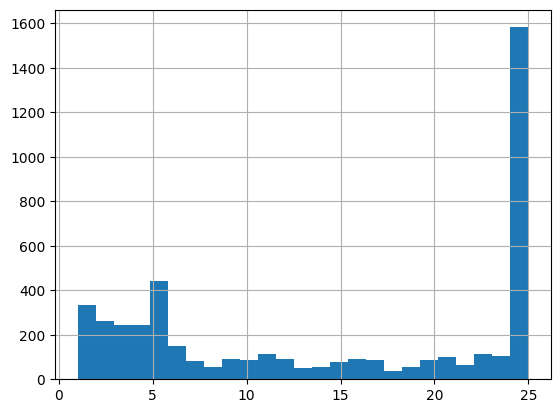

In [20]:
_filings['total'].hist(bins=25)

### Tickers Without Shares

In [21]:
_no_shares = (
    income_A.groupby('Ticker')[['Shares (Basic)', 'Shares (Diluted)']]
    .apply(lambda g: g.isna().all())
    .all(axis=1)
)
_no_shares_tickers = _no_shares[_no_shares].index.tolist()
print(f'Tickers with no shares data (annual): {len(_no_shares_tickers)}')
print(_no_shares_tickers)

Tickers with no shares data (annual): 71
['AHFC', 'ALC', 'ATCC', 'ATVCU', 'BFAC', 'BKUH', 'BP', 'BROG', 'CBRG', 'CCH', 'CEPU', 'CHAQ', 'CITE', 'CNTG', 'CPAC', 'CPSR', 'CTDD', 'ELBM', 'ENBL', 'FRLA', 'FSII', 'FURY', 'GAMB', 'GDEV', 'GFL', 'GGR', 'GGROU', 'GHRS', 'GWSO', 'ICR-PA', 'IHS', 'INFY', 'IQ', 'IVA', 'LANV', 'MDWD', 'MDXH', 'MOLN', 'NEN', 'NETDU', 'NMM', 'ONCYF', 'OTLY', 'PFTA', 'PHVS', 'POET', 'PRLH', 'PROC', 'QVC', 'ROCL', 'SAP', 'SFRX', 'SHLT', 'SOPH', 'SRNGU', 'STG', 'SVACU', 'TEO', 'TGAA', 'TIXT', 'TLGY', 'TLSA', 'TM-28', 'TRMR', 'TTE', 'VEON', 'WDS', 'WELPP', 'YJ', 'YOTA', 'ZGN']


### Duplicate Keys

In [22]:
_key = ['Ticker', 'Fiscal Year', 'Fiscal Period', 'Period']
for _name, _df in _stmt_map.items():
    _dups = _df[_df.duplicated(subset=_key, keep=False)]
    print(
        f'{_name}: {len(_dups)} duplicate rows across {_dups["Ticker"].nunique()} tickers'
    )
    if len(_dups):
        display(_dups[_key].sort_values(_key))

income: 0 duplicate rows across 0 tickers
balance: 0 duplicate rows across 0 tickers
cashflow: 0 duplicate rows across 0 tickers


### Annual Coverage Gaps

In [23]:
_gaps = []
for _ticker, _g in income_A.groupby('Ticker'):
    _years = sorted(_g['Fiscal Year'].unique())
    _missing = sorted(set(range(_years[0], _years[-1] + 1)) - set(_years))
    if _missing:
        _gaps.append(
            {'Ticker': _ticker, 'Missing Years': _missing, 'Count': len(_missing)}
        )

if _gaps:
    _gaps_df = (
        pd.DataFrame(_gaps).sort_values('Count', ascending=False).reset_index(drop=True)
    )
    print(f'Tickers with annual gaps: {len(_gaps_df)}')
    display(_gaps_df)
else:
    print('No annual coverage gaps found.')

No annual coverage gaps found.


### Quarterly Coverage Gaps

In [24]:
_expected_qtrs = {'Q1', 'Q2', 'Q3', 'Q4'}
_q_map = {'income': income_Q, 'balance': balance_Q, 'cashflow': cashflow_Q}

for _name, _df in _q_map.items():
    _fy_min = _df.groupby('Ticker')['Fiscal Year'].min().to_dict()
    _fy_max = _df.groupby('Ticker')['Fiscal Year'].max().to_dict()
    _gaps_q = []
    for (_ticker, _fy), _g in _df.groupby(['Ticker', 'Fiscal Year']):
        if _fy == _fy_min[_ticker] or _fy == _fy_max[_ticker]:
            continue
        _missing = sorted(_expected_qtrs - set(_g['Fiscal Period'].unique()))
        if _missing:
            _gaps_q.append({'Ticker': _ticker, 'Fiscal Year': int(_fy), 'Missing': _missing, 'Count': len(_missing)})

    if _gaps_q:
        _gaps_q_df = (
            pd.DataFrame(_gaps_q)
            .sort_values(['Count', 'Ticker', 'Fiscal Year'], ascending=[False, True, True])
            .reset_index(drop=True)
        )
        print(f'{_name}: {len(_gaps_q_df)} ticker/year combos with gaps  |  {_gaps_q_df["Ticker"].nunique()} tickers affected')
        display(_gaps_q_df)
    else:
        print(f'{_name}: no quarterly coverage gaps')

income: no quarterly coverage gaps
balance: 3 ticker/year combos with gaps  |  3 tickers affected


,Ticker,Fiscal Year,Missing,Count
0,AFRM,2022,[Q1],1
1,TDG,2021,[Q1],1
2,UA,2022,[Q1],1


cashflow: 1 ticker/year combos with gaps  |  1 tickers affected


,Ticker,Fiscal Year,Missing,Count
0,TDG,2021,[Q2],1


### Tickers Not in Companies Table

In [25]:
_comp_tickers = set(_companies()['Ticker'])
_fund_tickers = set(income['Ticker'])
_no_meta = sorted(_fund_tickers - _comp_tickers)
print(f'Tickers in fundamentals but not in companies: {len(_no_meta)}')
print(_no_meta)

Tickers in fundamentals but not in companies: 0
[]


### Currency Changes

In [26]:
_currency_changes = [
    {'Ticker': _t, 'Currencies': sorted(_g['Currency'].unique())}
    for _t, _g in income.groupby('Ticker')
    if _g['Currency'].nunique() > 1
]
_curr_df = pd.DataFrame(_currency_changes)
print(f'Tickers with currency changes: {len(_curr_df)}')
display(_curr_df)

Tickers with currency changes: 0


""
